<a href="https://colab.research.google.com/github/shahbaz11-arch/NNDDE/blob/main/Problem_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Solving the 4x4 nonlinear algebraic system using fsolve...

--- Discovered Network Weights ---
w0: 1.175201
w1: 1.103638
w2: 0.357814

--- Solution Evaluation (11 Test Points) ---
x     | y_approx     | y_exact (e^x)   | Relative Error 
-------------------------------------------------------
0.000 | 1.000000     | 1.000000        | 0.0000e+00     
0.100 | 1.105171     | 1.105171        | 6.0877e-14     
0.200 | 1.221403     | 1.221403        | 8.5989e-14     
0.300 | 1.349859     | 1.349859        | 3.1254e-14     
0.400 | 1.491825     | 1.491825        | 3.2150e-14     
0.500 | 1.648721     | 1.648721        | 3.3939e-14     
0.600 | 1.822119     | 1.822119        | 2.1569e-14     
0.700 | 2.013753     | 2.013753        | 5.3809e-14     
0.800 | 2.225541     | 2.225541        | 7.9817e-16     
0.900 | 2.459603     | 2.459603        | 1.9680e-14     
1.000 | 2.718282     | 2.718282        | 1.6468e-13     

--- Error Summary ---
Maximum Absolute Error: 4.4764e-13
Maximum Relative Error

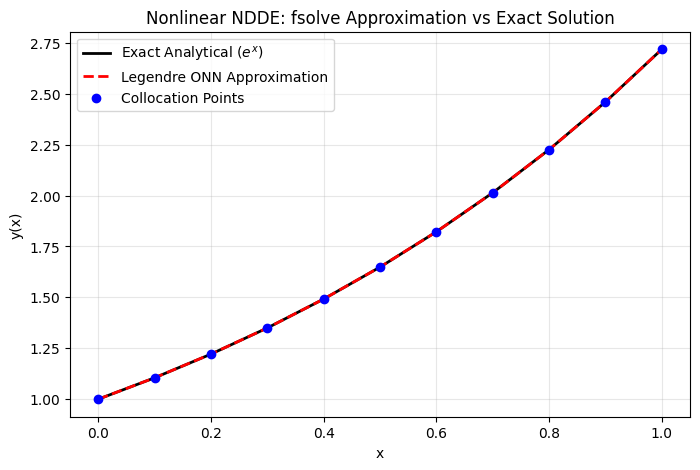

In [3]:
#Problem--6(Legendre)(Verified)
import torch
import numpy as np
from scipy.optimize import fsolve
import matplotlib.pyplot as plt

# ==========================================
# 1. Legendre Basis Implementation
# ==========================================
def get_Legendre_basis(x, n_polys):
    """
    Generates Legendre polynomials T_n(x) and T'_n(x)
    using recurrence relations for n = 0 to n_polys-1.
    """
    if x.dim() == 0:
        x = x.unsqueeze(0)

    num_points = len(x)
    T = torch.zeros(num_points, n_polys, dtype=torch.float64)
    T_d = torch.zeros(num_points, n_polys, dtype=torch.float64)

    # Base Case: n=0 -> T_0 = 1, T'_0 = 0
    T[:, 0] = 1.0

    if n_polys > 1:
        # Base Case: n=1 -> T_1 = x, T'_1 = 1
        T[:, 1] = x
        T_d[:, 1] = 1.0

    # Recurrence Loop for n >= 2
    for n in range(2, n_polys):
      T[:, n] = ((2.0 * n - 1.0) * x * T[:, n-1] - (n - 1.0) * T[:, n-2]) / n
      T_d[:, n] = ((2.0 * n - 1.0) * (T[:, n-1] + x * T_d[:, n-1]) - (n - 1.0) * T_d[:, n-2]) / n
    return T, T_d


def predict(x, w):
    """Returns y_approx and y'_approx for a given set of weights."""
    T, T_d = get_Legendre_basis(x, len(w))
    y = T @ w
    y_d = T_d @ w
    return y, y_d

# ==========================================
# 2. Problem Setup (LHS and RHS of NDDE)
# ==========================================
def compute_rhs(x):
    """Right Hand Side of the nonlinear NDDE."""
    sqrt_x = torch.sqrt(x)
    sin_x = torch.sin(x)

    term1 = torch.exp(2 * x)
    term2 = torch.sqrt(torch.cos(x)) * torch.exp(sqrt_x)
    term3 = (torch.sin(sqrt_x) + torch.exp(x)) * torch.exp(sin_x)

    return term1 + term2 + term3

def compute_lhs(x, w):
    """Left Hand Side of the nonlinear NDDE evaluated with current weights."""
    y_x, yd_x = predict(x, w)

    # Delayed/Transformed states
    sqrt_x = torch.sqrt(x)
    sin_x = torch.sin(x)

    _, yd_sqrt_x = predict(sqrt_x, w)
    y_sin_x, _ = predict(sin_x, w)

    term1 = y_x * yd_x
    term2 = torch.sqrt(torch.cos(x)) * yd_sqrt_x
    term3 = (torch.sin(sqrt_x) + torch.exp(x)) * y_sin_x

    return term1 + term2 + term3

# ==========================================
# 3. System of Equations for fsolve
# ==========================================
def algebraic_system(w_np):
    """
    Takes a numpy array of 4 weights and returns an array of 4 residuals.
    fsolve will try to drive these 4 residuals to exactly 0.
    """
    # Convert numpy array to PyTorch tensor
    w = torch.tensor(w_np, dtype=torch.float64)

    residuals = []

    # Equation 1: Initial Condition (y(0) = 1)
    x_0 = torch.tensor([0.0], dtype=torch.float64)
    y_0, _ = predict(x_0, w)
    residuals.append((y_0[0] - 1.0).item())

    # Equations 2, 3, 4: ODE Collocation at x = {0.0, 0.5, 1.0}
    colloc_points = torch.linspace(0,1,11,  dtype=torch.float64)

    lhs = compute_lhs(colloc_points, w)
    rhs = compute_rhs(colloc_points)

    ode_errors = lhs - rhs

    # Append the 3 ODE errors to the residuals list
    residuals.extend(ode_errors.tolist())

    return np.array(residuals)

# ==========================================
# 4. Solve using SciPy's fsolve
# ==========================================
print("Solving the 4x4 nonlinear algebraic system using fsolve...")

# Initial guess for the weights [w0, w1, w2, w3]
# We start with [1, 1, 0, 0] as a neutral guess
initial_guess = np.array([1.0, 1.0, 0.0,0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
                          0.0, 0.0 ])

# Run fsolve
w_sol_np = fsolve(algebraic_system, initial_guess)
w_sol = torch.tensor(w_sol_np, dtype=torch.float64)

print("\n--- Discovered Network Weights ---")
print(f"w0: {w_sol[0]:.6f}")
print(f"w1: {w_sol[1]:.6f}")
print(f"w2: {w_sol[2]:.6f}")
#print(f"w3: {w_sol[3]:.6f}")

# ==========================================
# 5. Evaluate and Plot
# ==========================================
print("\n--- Solution Evaluation (11 Test Points) ---")
print(f"{'x':<5} | {'y_approx':<12} | {'y_exact (e^x)':<15} | {'Relative Error':<15}")
print("-" * 55)

x_eval = torch.linspace(0, 1, 11, dtype=torch.float64)
y_approx, _ = predict(x_eval, w_sol)
y_exact = torch.exp(x_eval)

rel_errors = torch.abs(y_approx - y_exact) / torch.abs(y_exact)

for i in range(len(x_eval)):
    x_val = x_eval[i].item()
    approx_val = y_approx[i].item()
    exact_val = y_exact[i].item()
    err_val = rel_errors[i].item()
    print(f"{x_val:<5.3f} | {approx_val:<12.6f} | {exact_val:<15.6f} | {err_val:<15.4e}")

 # ==========================================
# Calculate and Print Maximum Errors
# ==========================================

# 1. Calculate Maximum Absolute Error
abs_errors = torch.abs(y_approx - y_exact)
max_abs_err = torch.max(abs_errors).item()

# 2. Calculate Maximum Relative Error (safely handling division by zero)
rel_errors = torch.zeros_like(x_eval)
for i in range(len(x_eval)):
    if y_exact[i] == 0.0:
        rel_errors[i] = abs_errors[i]  # Fallback to absolute error if exact is 0
    else:
        rel_errors[i] = abs_errors[i] / torch.abs(y_exact[i])

max_rel_err = torch.max(rel_errors).item()

# 3. Print Results
print("\n--- Error Summary ---")
print(f"Maximum Absolute Error: {max_abs_err:.4e}")
print(f"Maximum Relative Error: {max_rel_err:.4e}")

# Visualization
plt.figure(figsize=(8, 5))
plt.plot(x_eval.numpy(), y_exact.numpy(), 'k-', linewidth=2, label='Exact Analytical ($e^x$)')
plt.plot(x_eval.numpy(), y_approx.numpy(), 'r--', linewidth=2, label='Legendre ONN Approximation')
plt.scatter(torch.linspace(0,1,11), predict(torch.linspace(0,1,11,  dtype=torch.float64), w_sol)[0].numpy(),
            color='blue', zorder=5, label='Collocation Points')
plt.title("Nonlinear NDDE: fsolve Approximation vs Exact Solution")
plt.xlabel("x")
plt.ylabel("y(x)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Solving the 4x4 nonlinear algebraic system using fsolve...

--- Discovered Network Weights ---
w0: 1.266066
w1: 1.130318
w2: 0.271495
w3: 0.044337

--- Solution Evaluation (10 Test Points) ---
x     | y_approx     | y_exact (e^x)   | Relative Error 
-------------------------------------------------------
0.000 | 1.000000     | 1.000000        | 0.0000e+00     
0.111 | 1.117519     | 1.117519        | 7.7491e-15     
0.222 | 1.248849     | 1.248849        | 4.9784e-15     
0.333 | 1.395612     | 1.395612        | 3.5002e-15     
0.444 | 1.559623     | 1.559623        | 1.9932e-15     
0.556 | 1.742909     | 1.742909        | 1.9110e-15     
0.667 | 1.947734     | 1.947734        | 2.0520e-15     
0.778 | 2.176630     | 2.176630        | 8.1610e-16     
0.889 | 2.432425     | 2.432425        | 9.1285e-16     
1.000 | 2.718282     | 2.718282        | 1.7971e-15     

--- Error Summary ---
Maximum Absolute Error: 8.6597e-15
Maximum Relative Error: 7.7491e-15


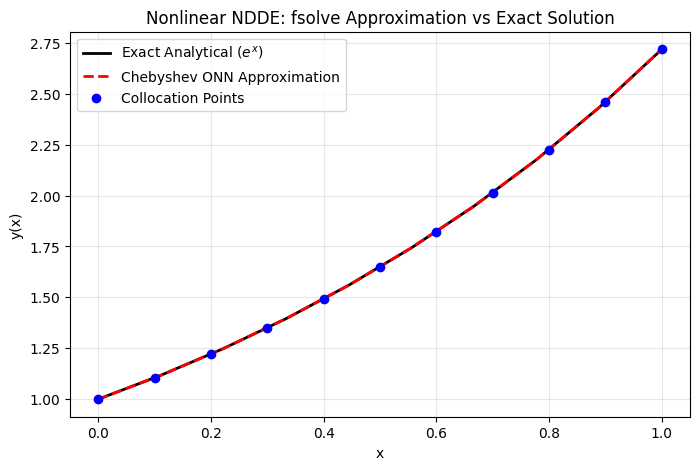

In [2]:
#Problem--6(Chebyshev)(Verified)
import torch
import numpy as np
from scipy.optimize import fsolve
import matplotlib.pyplot as plt

# ==========================================
# 1. Chebyshev Basis Implementation
# ==========================================
def get_chebyshev_basis(x, n_polys):
    """
    Generates Chebyshev polynomials T_n(x) and T'_n(x)
    using recurrence relations for n = 0 to n_polys-1.
    """
    if x.dim() == 0:
        x = x.unsqueeze(0)

    num_points = len(x)
    T = torch.zeros(num_points, n_polys, dtype=torch.float64)
    T_d = torch.zeros(num_points, n_polys, dtype=torch.float64)

    # Base Case: n=0 -> T_0 = 1, T'_0 = 0
    T[:, 0] = 1.0

    if n_polys > 1:
        # Base Case: n=1 -> T_1 = x, T'_1 = 1
        T[:, 1] = x
        T_d[:, 1] = 1.0

    # Recurrence Loop for n >= 2
    for n in range(2, n_polys):
        T[:, n] = 2 * x * T[:, n-1] - T[:, n-2]
        T_d[:, n] = 2 * T[:, n-1] + 2 * x * T_d[:, n-1] - T_d[:, n-2]

    return T, T_d

def predict(x, w):
    """Returns y_approx and y'_approx for a given set of weights."""
    T, T_d = get_chebyshev_basis(x, len(w))
    y = T @ w
    y_d = T_d @ w
    return y, y_d

# ==========================================
# 2. Problem Setup (LHS and RHS of NDDE)
# ==========================================
def compute_rhs(x):
    """Right Hand Side of the nonlinear NDDE."""
    sqrt_x = torch.sqrt(x)
    sin_x = torch.sin(x)

    term1 = torch.exp(2 * x)
    term2 = torch.sqrt(torch.cos(x)) * torch.exp(sqrt_x)
    term3 = (torch.sin(sqrt_x) + torch.exp(x)) * torch.exp(sin_x)

    return term1 + term2 + term3

def compute_lhs(x, w):
    """Left Hand Side of the nonlinear NDDE evaluated with current weights."""
    y_x, yd_x = predict(x, w)

    # Delayed/Transformed states
    sqrt_x = torch.sqrt(x)
    sin_x = torch.sin(x)

    _, yd_sqrt_x = predict(sqrt_x, w)
    y_sin_x, _ = predict(sin_x, w)

    term1 = y_x * yd_x
    term2 = torch.sqrt(torch.cos(x)) * yd_sqrt_x
    term3 = (torch.sin(sqrt_x) + torch.exp(x)) * y_sin_x

    return term1 + term2 + term3

# ==========================================
# 3. System of Equations for fsolve
# ==========================================
def algebraic_system(w_np):
    """
    Takes a numpy array of 4 weights and returns an array of 4 residuals.
    fsolve will try to drive these 4 residuals to exactly 0.
    """
    # Convert numpy array to PyTorch tensor
    w = torch.tensor(w_np, dtype=torch.float64)

    residuals = []

    # Equation 1: Initial Condition (y(0) = 1)
    x_0 = torch.tensor([0.0], dtype=torch.float64)
    y_0, _ = predict(x_0, w)
    residuals.append((y_0[0] - 1.0).item())

    # Equations 2, 3, 4: ODE Collocation at x = {0.0, 0.5, 1.0}
    colloc_points = torch.linspace(0,1,11,  dtype=torch.float64)

    lhs = compute_lhs(colloc_points, w)
    rhs = compute_rhs(colloc_points)

    ode_errors = lhs - rhs

    # Append the 3 ODE errors to the residuals list
    residuals.extend(ode_errors.tolist())

    return np.array(residuals)

# ==========================================
# 4. Solve using SciPy's fsolve
# ==========================================
print("Solving the 4x4 nonlinear algebraic system using fsolve...")

# Initial guess for the weights [w0, w1, w2, w3]
# We start with [1, 1, 0, 0] as a neutral guess
initial_guess = np.array([1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
                          0.0, 0.0])

# Run fsolve
w_sol_np = fsolve(algebraic_system, initial_guess)
w_sol = torch.tensor(w_sol_np, dtype=torch.float64)

print("\n--- Discovered Network Weights ---")
print(f"w0: {w_sol[0]:.6f}")
print(f"w1: {w_sol[1]:.6f}")
print(f"w2: {w_sol[2]:.6f}")
print(f"w3: {w_sol[3]:.6f}")

# ==========================================
# 5. Evaluate and Plot
# ==========================================
print("\n--- Solution Evaluation (10 Test Points) ---")
print(f"{'x':<5} | {'y_approx':<12} | {'y_exact (e^x)':<15} | {'Relative Error':<15}")
print("-" * 55)

x_eval = torch.linspace(0, 1, 10, dtype=torch.float64)
y_approx, _ = predict(x_eval, w_sol)
y_exact = torch.exp(x_eval)

rel_errors = torch.abs(y_approx - y_exact) / torch.abs(y_exact)

for i in range(len(x_eval)):
    x_val = x_eval[i].item()
    approx_val = y_approx[i].item()
    exact_val = y_exact[i].item()
    err_val = rel_errors[i].item()
    print(f"{x_val:<5.3f} | {approx_val:<12.6f} | {exact_val:<15.6f} | {err_val:<15.4e}")

  # ==========================================
# Calculate and Print Maximum Errors
# ==========================================

# 1. Calculate Maximum Absolute Error
abs_errors = torch.abs(y_approx - y_exact)
max_abs_err = torch.max(abs_errors).item()

# 2. Calculate Maximum Relative Error (safely handling division by zero)
rel_errors = torch.zeros_like(x_eval)
for i in range(len(x_eval)):
    if y_exact[i] == 0.0:
        rel_errors[i] = abs_errors[i]  # Fallback to absolute error if exact is 0
    else:
        rel_errors[i] = abs_errors[i] / torch.abs(y_exact[i])

max_rel_err = torch.max(rel_errors).item()

# 3. Print Results
print("\n--- Error Summary ---")
print(f"Maximum Absolute Error: {max_abs_err:.4e}")
print(f"Maximum Relative Error: {max_rel_err:.4e}")

# Visualization
plt.figure(figsize=(8, 5))
plt.plot(x_eval.numpy(), y_exact.numpy(), 'k-', linewidth=2, label='Exact Analytical ($e^x$)')
plt.plot(x_eval.numpy(), y_approx.numpy(), 'r--', linewidth=2, label='Chebyshev ONN Approximation')
plt.scatter(torch.linspace(0,1,11, dtype=torch.float64), predict(torch.linspace(0,1,11, dtype=torch.float64), w_sol)[0].numpy(),
            color='blue', zorder=5, label='Collocation Points')
plt.title("Nonlinear NDDE: fsolve Approximation vs Exact Solution")
plt.xlabel("x")
plt.ylabel("y(x)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Solving the 4x4 nonlinear algebraic system using fsolve...


/tmp/ipykernel_237/230535383.py:116: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  w_sol_np = fsolve(algebraic_system, initial_guess)



--- Discovered Network Weights ---
w0: 1.655668
w1: 1.628278
w2: 0.855350

--- Solution Evaluation (10 Test Points) ---
x     | y_approx     | y_exact (e^x)   | Relative Error 
-------------------------------------------------------
0.000 | 1.000000     | 1.000000        | 2.2831e-12     
0.100 | 1.105171     | 1.105171        | 4.0453e-11     
0.200 | 1.221403     | 1.221403        | 3.0963e-11     
0.300 | 1.349859     | 1.349859        | 1.4100e-11     
0.400 | 1.491825     | 1.491825        | 5.6743e-12     
0.500 | 1.648721     | 1.648721        | 8.2533e-12     
0.600 | 1.822119     | 1.822119        | 7.9420e-12     
0.700 | 2.013753     | 2.013753        | 1.2760e-11     
0.800 | 2.225541     | 2.225541        | 4.2652e-12     
0.900 | 2.459603     | 2.459603        | 5.9852e-12     
1.000 | 2.718282     | 2.718282        | 7.9921e-13     

--- Error Summary ---
Maximum Absolute Error: 4.4707e-11
Maximum Relative Error: 4.0453e-11


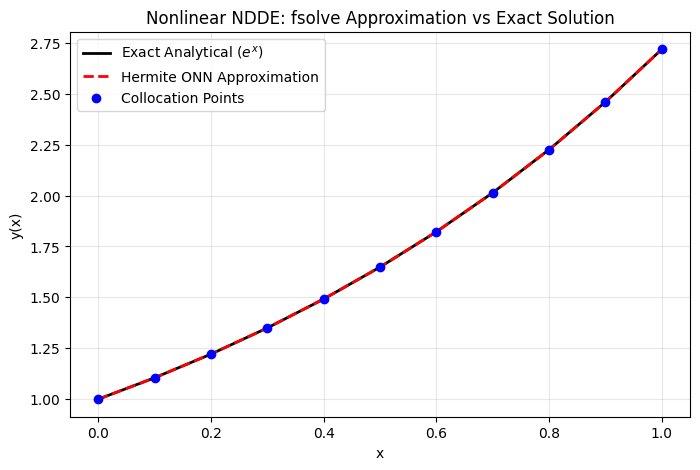

In [1]:
#Problem--6(Hermite)(Verified)
import torch
import numpy as np
from scipy.optimize import fsolve
import matplotlib.pyplot as plt

# ==========================================
# 1. Hermite Basis Implementation
# ==========================================
def get_Hermite_basis(x, n_polys):
    """
    Generates Hermite polynomials T_n(x) and T'_n(x)
    using recurrence relations for n = 0 to n_polys-1.
    """
    if x.dim() == 0:
        x = x.unsqueeze(0)

    num_points = len(x)
    T = torch.zeros(num_points, n_polys, dtype=torch.float64)
    T_d = torch.zeros(num_points, n_polys, dtype=torch.float64)

    # Base Case: n=0 -> T_0 = 1, T'_0 = 0
    T[:, 0] = 1.0

    if n_polys > 1:
        # Base Case: n=1 -> T_1 = x, T'_1 = 1
        T[:, 1] = x
        T_d[:, 1] = 1.0

    # Recurrence Loop for n >= 2
    for n in range(2, n_polys):
        T[:, n] = x * T[:, n-1] - (n - 1.0) * T[:, n-2]
        T_d[:, n] = float(n) * T[:, n-1]

    return T, T_d

def predict(x, w):
    """Returns y_approx and y'_approx for a given set of weights."""
    T, T_d = get_Hermite_basis(x, len(w))
    y = T @ w
    y_d = T_d @ w
    return y, y_d

# ==========================================
# 2. Problem Setup (LHS and RHS of NDDE)
# ==========================================
def compute_rhs(x):
    """Right Hand Side of the nonlinear NDDE."""
    sqrt_x = torch.sqrt(x)
    sin_x = torch.sin(x)

    term1 = torch.exp(2 * x)
    term2 = torch.sqrt(torch.cos(x)) * torch.exp(sqrt_x)
    term3 = (torch.sin(sqrt_x) + torch.exp(x)) * torch.exp(sin_x)

    return term1 + term2 + term3

def compute_lhs(x, w):
    """Left Hand Side of the nonlinear NDDE evaluated with current weights."""
    y_x, yd_x = predict(x, w)

    # Delayed/Transformed states
    sqrt_x = torch.sqrt(x)
    sin_x = torch.sin(x)

    _, yd_sqrt_x = predict(sqrt_x, w)
    y_sin_x, _ = predict(sin_x, w)

    term1 = y_x * yd_x
    term2 = torch.sqrt(torch.cos(x)) * yd_sqrt_x
    term3 = (torch.sin(sqrt_x) + torch.exp(x)) * y_sin_x

    return term1 + term2 + term3

# ==========================================
# 3. System of Equations for fsolve
# ==========================================
def algebraic_system(w_np):
    """
    Takes a numpy array of 4 weights and returns an array of 4 residuals.
    fsolve will try to drive these 4 residuals to exactly 0.
    """
    # Convert numpy array to PyTorch tensor
    w = torch.tensor(w_np, dtype=torch.float64)

    residuals = []

    # Equation 1: Initial Condition (y(0) = 1)
    x_0 = torch.tensor([0.0], dtype=torch.float64)
    y_0, _ = predict(x_0, w)
    residuals.append((y_0[0] - 1.0).item())

    # Equations 2, 3, 4: ODE Collocation at x = {0.0, 0.5, 1.0}
    colloc_points = torch.linspace(0,1,11,  dtype=torch.float64)

    lhs = compute_lhs(colloc_points, w)
    rhs = compute_rhs(colloc_points)

    ode_errors = lhs - rhs

    # Append the 3 ODE errors to the residuals list
    residuals.extend(ode_errors.tolist())

    return np.array(residuals)

# ==========================================
# 4. Solve using SciPy's fsolve
# ==========================================
print("Solving the 4x4 nonlinear algebraic system using fsolve...")

# Initial guess for the weights [w0, w1, w2, w3]
# We start with [1, 1, 0, 0] as a neutral guess
initial_guess = np.array([1.0, 1.0, 0.0,0.0, 0.0, 0.0,0.0, 0.0, 0.0,0.0,0.0, 0.0])

# Run fsolve
w_sol_np = fsolve(algebraic_system, initial_guess)
w_sol = torch.tensor(w_sol_np, dtype=torch.float64)

print("\n--- Discovered Network Weights ---")
print(f"w0: {w_sol[0]:.6f}")
print(f"w1: {w_sol[1]:.6f}")
print(f"w2: {w_sol[2]:.6f}")
#print(f"w3: {w_sol[3]:.6f}")

# ==========================================
# 5. Evaluate and Plot
# ==========================================
print("\n--- Solution Evaluation (10 Test Points) ---")
print(f"{'x':<5} | {'y_approx':<12} | {'y_exact (e^x)':<15} | {'Relative Error':<15}")
print("-" * 55)

x_eval = torch.linspace(0, 1, 11, dtype=torch.float64)
y_approx, _ = predict(x_eval, w_sol)
y_exact = torch.exp(x_eval)

rel_errors = torch.abs(y_approx - y_exact) / torch.abs(y_exact)

for i in range(len(x_eval)):
    x_val = x_eval[i].item()
    approx_val = y_approx[i].item()
    exact_val = y_exact[i].item()
    err_val = rel_errors[i].item()
    print(f"{x_val:<5.3f} | {approx_val:<12.6f} | {exact_val:<15.6f} | {err_val:<15.4e}")

# ==========================================
# Calculate and Print Maximum Errors
# ==========================================

# 1. Calculate Maximum Absolute Error
abs_errors = torch.abs(y_approx - y_exact)
max_abs_err = torch.max(abs_errors).item()

# 2. Calculate Maximum Relative Error (safely handling division by zero)
rel_errors = torch.zeros_like(x_eval)
for i in range(len(x_eval)):
    if y_exact[i] == 0.0:
        rel_errors[i] = abs_errors[i]  # Fallback to absolute error if exact is 0
    else:
        rel_errors[i] = abs_errors[i] / torch.abs(y_exact[i])

max_rel_err = torch.max(rel_errors).item()

# 3. Print Results
print("\n--- Error Summary ---")
print(f"Maximum Absolute Error: {max_abs_err:.4e}")
print(f"Maximum Relative Error: {max_rel_err:.4e}")

# Visualization
plt.figure(figsize=(8, 5))
plt.plot(x_eval.numpy(), y_exact.numpy(), 'k-', linewidth=2, label='Exact Analytical ($e^x$)')
plt.plot(x_eval.numpy(), y_approx.numpy(), 'r--', linewidth=2, label='Hermite ONN Approximation')
plt.scatter(torch.linspace(0,1,11, dtype=torch.float64), predict(torch.linspace(0,1,11, dtype=torch.float64), w_sol)[0].numpy(),
            color='blue', zorder=5, label='Collocation Points')
plt.title("Nonlinear NDDE: fsolve Approximation vs Exact Solution")
plt.xlabel("x")
plt.ylabel("y(x)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()